In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("AmesHousing.csv")
display(df)
print(df.shape)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


(2930, 82)


In [3]:
df.isna().sum()

Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

In [4]:
df.drop(columns = ["PID","Order"], inplace = True)
df = df[df['Gr Liv Area'] < 3500]

In [5]:
dfs = df.drop(columns = df.select_dtypes("number").columns.tolist())
dfn = df.select_dtypes("number")

In [6]:
dfs

,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
0,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,...,Attchd,Fin,TA,TA,P,NaN,NaN,NaN,WD,Normal
1,RH,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,...,Attchd,Unf,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
2,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,NaN,NaN,Gar2,WD,Normal
3,RL,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,...,Attchd,Fin,TA,TA,Y,NaN,NaN,NaN,WD,Normal
4,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,...,Attchd,Fin,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,RL,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,Mitchel,Norm,...,Detchd,Unf,TA,TA,Y,NaN,GdPrv,NaN,WD,Normal
2926,RL,Pave,NaN,IR1,Low,AllPub,Inside,Mod,Mitchel,Norm,...,Attchd,Unf,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
2927,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,...,NaN,NaN,NaN,NaN,Y,NaN,MnPrv,Shed,WD,Normal
2928,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Mod,Mitchel,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal


In [7]:
for col in dfs.columns:
    print (col,df[col].unique().tolist())

MS Zoning ['RL', 'RH', 'FV', 'RM', 'C (all)', 'I (all)', 'A (agr)']
Street ['Pave', 'Grvl']
Alley [nan, 'Pave', 'Grvl']
Lot Shape ['IR1', 'Reg', 'IR2', 'IR3']
Land Contour ['Lvl', 'HLS', 'Bnk', 'Low']
Utilities ['AllPub', 'NoSewr', 'NoSeWa']
Lot Config ['Corner', 'Inside', 'CulDSac', 'FR2', 'FR3']
Land Slope ['Gtl', 'Mod', 'Sev']
Neighborhood ['NAmes', 'Gilbert', 'StoneBr', 'NWAmes', 'Somerst', 'BrDale', 'NPkVill', 'NridgHt', 'Blmngtn', 'NoRidge', 'SawyerW', 'Sawyer', 'Greens', 'BrkSide', 'OldTown', 'IDOTRR', 'ClearCr', 'SWISU', 'Edwards', 'CollgCr', 'Crawfor', 'Blueste', 'Mitchel', 'Timber', 'MeadowV', 'Veenker', 'GrnHill', 'Landmrk']
Condition 1 ['Norm', 'Feedr', 'PosN', 'RRNe', 'RRAe', 'Artery', 'PosA', 'RRAn', 'RRNn']
Condition 2 ['Norm', 'Feedr', 'PosA', 'PosN', 'Artery', 'RRNn', 'RRAe', 'RRAn']
Bldg Type ['1Fam', 'TwnhsE', 'Twnhs', 'Duplex', '2fmCon']
House Style ['1Story', '2Story', '1.5Fin', 'SFoyer', 'SLvl', '2.5Unf', '1.5Unf', '2.5Fin']
Roof Style ['Hip', 'Gable', 'Mansard', 

In [8]:
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0, np.nan: 0}
expo_map = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'NA': 0, np.nan: 0}
bsmt_fin_map = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'NA': 0, np.nan: 0}
garage_fin_map = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'NA': 0, np.nan: 0}
shape_map = {'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1, np.nan: 0}
slope_map = {'Gtl': 3, 'Mod': 2, 'Sev': 1, np.nan: 0}
util_map = {'AllPub': 4, 'NoSewr': 3, 'NoSeWa': 2, 'ELO': 1, np.nan: 0}
func_map = {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0, np.nan: 7}
paved_map = {'Y': 2, 'P': 1, 'N': 0, np.nan: 0}
fence_map = {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'NA': 0, np.nan: 0}

qual_cols = ['Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond', 'Heating QC', 'Kitchen Qual', 'Fireplace Qu', 'Garage Qual', 'Garage Cond', 'Pool QC']

for col in qual_cols:
    dfs[col] = dfs[col].map(qual_map)

mappings = {
    'Bsmt Exposure': expo_map,
    'BsmtFin Type 1': bsmt_fin_map,
    'BsmtFin Type 2': bsmt_fin_map,
    'Garage Finish': garage_fin_map,
    'Lot Shape': shape_map,
    'Land Slope': slope_map,
    'Utilities': util_map,
    'Functional': func_map,
    'Paved Drive': paved_map,
    'Fence': fence_map
}

for col, mapping in mappings.items():
    dfs[col] = dfs[col].map(mapping)

In [9]:
dfs.info()

<class 'pandas.DataFrame'>
Index: 2920 entries, 0 to 2929
Data columns (total 43 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   MS Zoning       2920 non-null   str  
 1   Street          2920 non-null   str  
 2   Alley           198 non-null    str  
 3   Lot Shape       2920 non-null   int64
 4   Land Contour    2920 non-null   str  
 5   Utilities       2920 non-null   int64
 6   Lot Config      2920 non-null   str  
 7   Land Slope      2920 non-null   int64
 8   Neighborhood    2920 non-null   str  
 9   Condition 1     2920 non-null   str  
 10  Condition 2     2920 non-null   str  
 11  Bldg Type       2920 non-null   str  
 12  House Style     2920 non-null   str  
 13  Roof Style      2920 non-null   str  
 14  Roof Matl       2920 non-null   str  
 15  Exterior 1st    2920 non-null   str  
 16  Exterior 2nd    2920 non-null   str  
 17  Mas Vnr Type    1149 non-null   str  
 18  Exter Qual      2920 non-null   int64
 19  E

In [10]:
for col in dfs.select_dtypes("number").columns:
    dfn[col] = dfs[col]
    dfs.drop(columns = col, inplace = True)
dfs = pd.get_dummies(dfs, dtype = int)
dfn.info()

<class 'pandas.DataFrame'>
Index: 2920 entries, 0 to 2929
Data columns (total 57 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2920 non-null   int64  
 1   Lot Frontage     2430 non-null   float64
 2   Lot Area         2920 non-null   int64  
 3   Overall Qual     2920 non-null   int64  
 4   Overall Cond     2920 non-null   int64  
 5   Year Built       2920 non-null   int64  
 6   Year Remod/Add   2920 non-null   int64  
 7   Mas Vnr Area     2897 non-null   float64
 8   BsmtFin SF 1     2919 non-null   float64
 9   BsmtFin SF 2     2919 non-null   float64
 10  Bsmt Unf SF      2919 non-null   float64
 11  Total Bsmt SF    2919 non-null   float64
 12  1st Flr SF       2920 non-null   int64  
 13  2nd Flr SF       2920 non-null   int64  
 14  Low Qual Fin SF  2920 non-null   int64  
 15  Gr Liv Area      2920 non-null   int64  
 16  Bsmt Full Bath   2919 non-null   float64
 17  Bsmt Half Bath   2919 non-null

In [11]:
dff = pd.concat([dfs, dfn], axis=1)
dff

,MS Zoning_A (agr),MS Zoning_C (all),MS Zoning_FV,MS Zoning_I (all),MS Zoning_RH,MS Zoning_RL,MS Zoning_RM,Street_Grvl,Street_Pave,Alley_Grvl,...,Heating QC,Kitchen Qual,Functional,Fireplace Qu,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence
0,0,0,0,0,0,1,0,0,1,0,...,2,3,7,4,3,3,3,1,0,0
1,0,0,0,0,1,0,0,0,1,0,...,3,3,7,0,1,3,3,2,0,3
2,0,0,0,0,0,1,0,0,1,0,...,3,4,7,0,1,3,3,2,0,0
3,0,0,0,0,0,1,0,0,1,0,...,5,5,7,3,3,3,3,2,0,0
4,0,0,0,0,0,1,0,0,1,0,...,4,3,7,3,3,3,3,2,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,0,0,0,0,0,1,0,0,1,0,...,3,3,7,0,1,3,3,2,0,4
2926,0,0,0,0,0,1,0,0,1,0,...,3,3,7,0,1,3,3,2,0,3
2927,0,0,0,0,0,1,0,0,1,0,...,3,3,7,0,0,0,0,2,0,3
2928,0,0,0,0,0,1,0,0,1,0,...,4,3,7,3,2,3,3,2,0,0


In [12]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=2)
cools = dff.columns
dff = imputer.fit_transform(dff)
dff = pd.DataFrame(dff, columns = cools)
dff.isna().sum()

MS Zoning_A (agr)    0
MS Zoning_C (all)    0
MS Zoning_FV         0
MS Zoning_I (all)    0
MS Zoning_RH         0
                    ..
Garage Qual          0
Garage Cond          0
Paved Drive          0
Pool QC              0
Fence                0
Length: 230, dtype: int64

In [13]:
df_50 = pd.DataFrame()
for col in dff.columns:
    if df["SalePrice"].corr(dff[col])>= 0.5:
        df_50[col] = dff[col]
display(df_50.info())

<class 'pandas.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Overall Qual   2920 non-null   float64
 1   Year Built     2920 non-null   float64
 2   Total Bsmt SF  2920 non-null   float64
 3   Gr Liv Area    2920 non-null   float64
 4   Garage Yr Blt  2920 non-null   float64
 5   Garage Cars    2920 non-null   float64
 6   Garage Area    2920 non-null   float64
 7   SalePrice      2920 non-null   float64
 8   Exter Qual     2920 non-null   float64
 9   Bsmt Qual      2920 non-null   float64
 10  Kitchen Qual   2920 non-null   float64
dtypes: float64(11)
memory usage: 251.1 KB


None

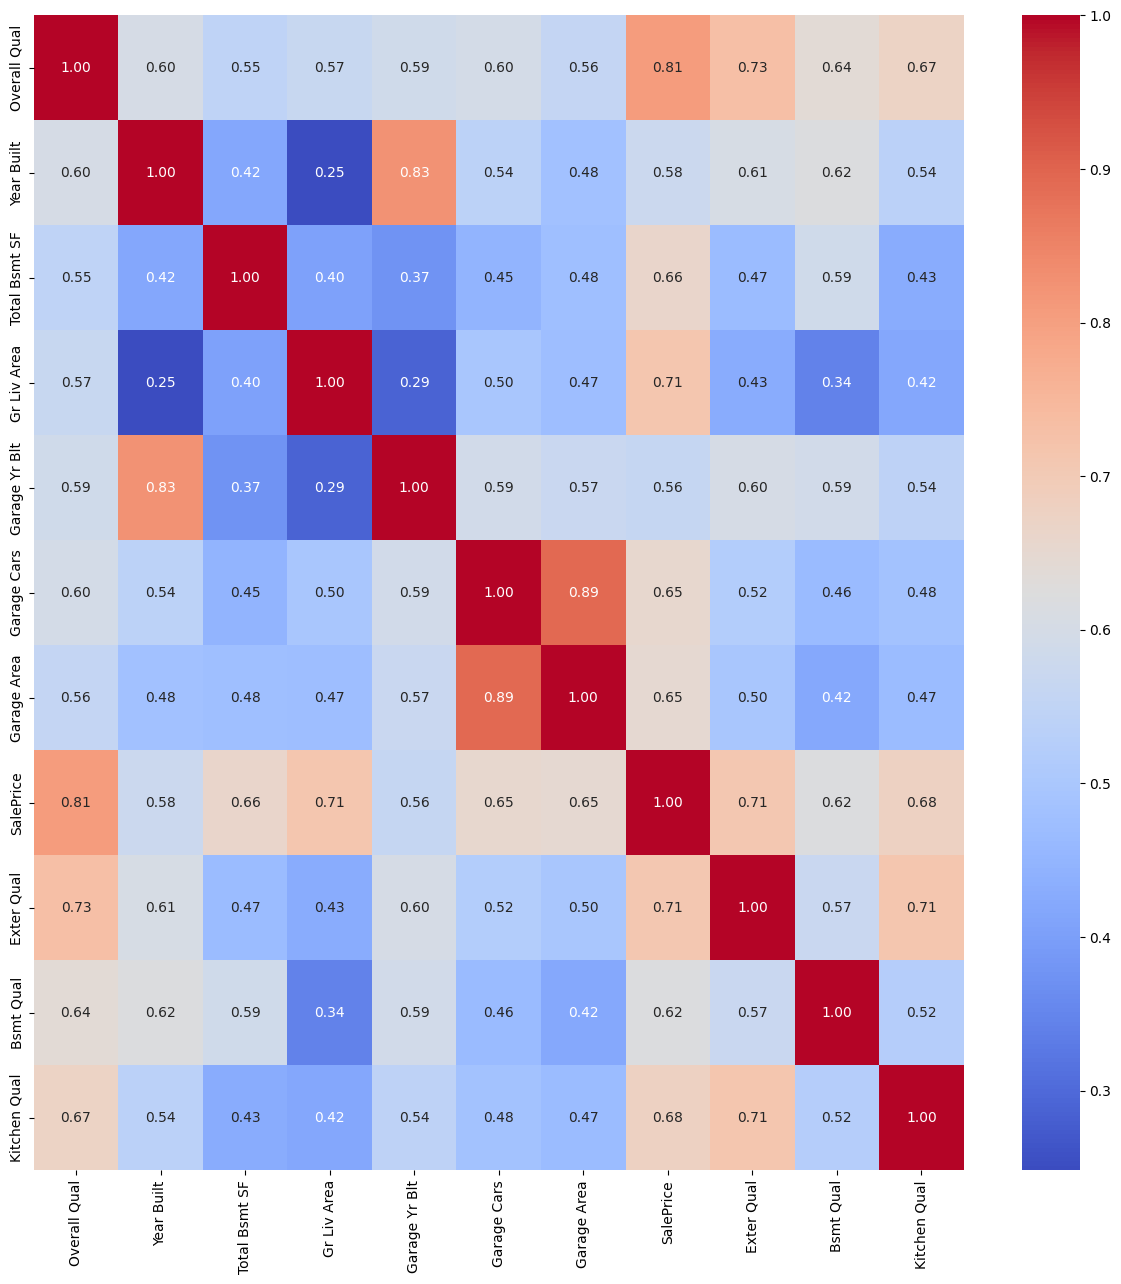

In [14]:
plt.figure(figsize=(15, 15))
sns.heatmap(df_50.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [15]:
def drop_redundant_features_dynamic(df, target_col):
    corr = df.corr(numeric_only=True).abs()

    target_corr = corr[target_col].drop(target_col)
    cols = [c for c in corr.columns if c != target_col]

    to_drop = set()

    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            c1, c2 = cols[i], cols[j]

            if c1 in to_drop or c2 in to_drop:
                continue

            pair_corr = corr.loc[c1, c2]
            c1_target = target_corr[c1]
            c2_target = target_corr[c2]

            # Drop if the two features are more correlated with each other
            # than either is with the target
            if pair_corr > c1_target and pair_corr > c2_target:
                if c1_target < c2_target:
                    to_drop.add(c1)
                else:
                    to_drop.add(c2)

    reduced_df = df.drop(columns=list(to_drop))
    return reduced_df

In [16]:
red_df = drop_redundant_features_dynamic(df_50, "SalePrice")
red_df

,Overall Qual,Year Built,Total Bsmt SF,Gr Liv Area,Garage Cars,SalePrice,Exter Qual,Bsmt Qual
0,6.0,1960.0,1080.0,1656.0,2.0,215000.0,3.0,3.0
1,5.0,1961.0,882.0,896.0,1.0,105000.0,3.0,3.0
2,6.0,1958.0,1329.0,1329.0,1.0,172000.0,3.0,3.0
3,7.0,1968.0,2110.0,2110.0,2.0,244000.0,4.0,3.0
4,5.0,1997.0,928.0,1629.0,2.0,189900.0,3.0,4.0
...,...,...,...,...,...,...,...,...
2915,6.0,1984.0,1003.0,1003.0,2.0,142500.0,3.0,3.0
2916,5.0,1983.0,864.0,902.0,2.0,131000.0,3.0,4.0
2917,5.0,1992.0,912.0,970.0,0.0,132000.0,3.0,4.0
2918,5.0,1974.0,1389.0,1389.0,2.0,170000.0,3.0,4.0


In [17]:
df_50 

,Overall Qual,Year Built,Total Bsmt SF,Gr Liv Area,Garage Yr Blt,Garage Cars,Garage Area,SalePrice,Exter Qual,Bsmt Qual,Kitchen Qual
0,6.0,1960.0,1080.0,1656.0,1960.0,2.0,528.0,215000.0,3.0,3.0,3.0
1,5.0,1961.0,882.0,896.0,1961.0,1.0,730.0,105000.0,3.0,3.0,3.0
2,6.0,1958.0,1329.0,1329.0,1958.0,1.0,312.0,172000.0,3.0,3.0,4.0
3,7.0,1968.0,2110.0,2110.0,1968.0,2.0,522.0,244000.0,4.0,3.0,5.0
4,5.0,1997.0,928.0,1629.0,1997.0,2.0,482.0,189900.0,3.0,4.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...
2915,6.0,1984.0,1003.0,1003.0,1984.0,2.0,588.0,142500.0,3.0,3.0,3.0
2916,5.0,1983.0,864.0,902.0,1983.0,2.0,484.0,131000.0,3.0,4.0,3.0
2917,5.0,1992.0,912.0,970.0,1962.5,0.0,0.0,132000.0,3.0,4.0,3.0
2918,5.0,1974.0,1389.0,1389.0,1975.0,2.0,418.0,170000.0,3.0,4.0,3.0


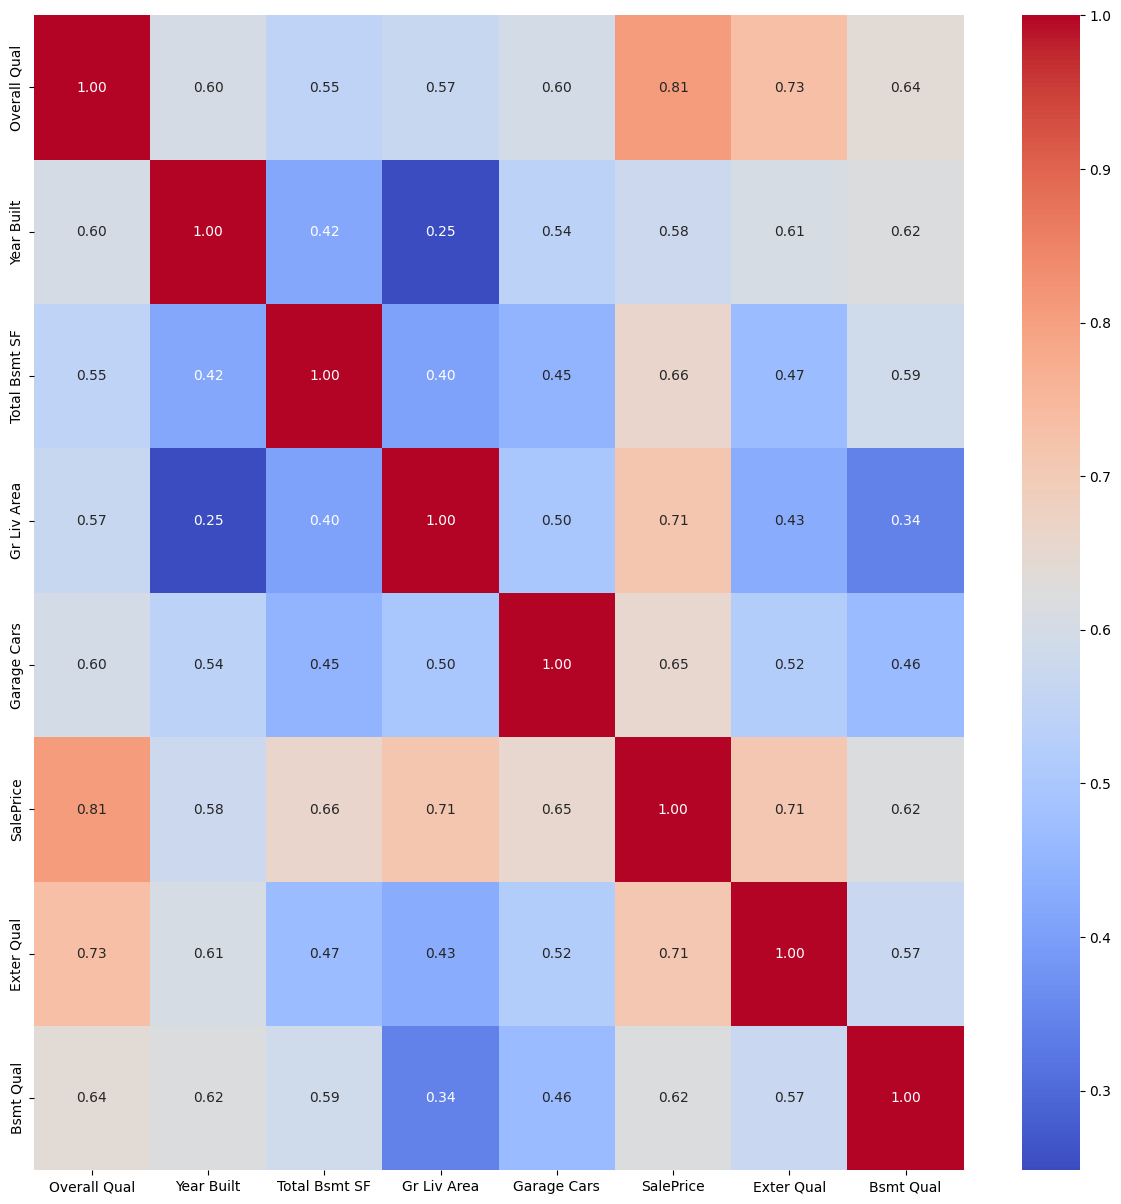

In [18]:
plt.figure(figsize=(15, 15))
sns.heatmap(red_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [19]:
x = red_df.drop(columns = "SalePrice")
y = red_df["SalePrice"]

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,y,train_size=0.8 , random_state = 2)

In [21]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression
feature_scaler = make_pipeline(MinMaxScaler(), LinearRegression())
model = TransformedTargetRegressor(
    regressor=feature_scaler,
    func=np.log1p,
    inverse_func=np.expm1
)

model.fit(X_train, y_train)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...egression())])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
y_test_mean = np.mean(y_test)
relative_rmse = rmse / y_test_mean
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print("-" * 30)
print(f"R-squared (R2): {r_squared:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2%}")
print(f"Relative RMSE (Error to Mean ratio): {relative_rmse:.2%}")

Mean Absolute Error (MAE): 18,487.76
Root Mean Squared Error (RMSE): 25,902.62
------------------------------
R-squared (R2): 0.8825
Mean Absolute Percentage Error (MAPE): 11.03%
Relative RMSE (Error to Mean ratio): 14.43%


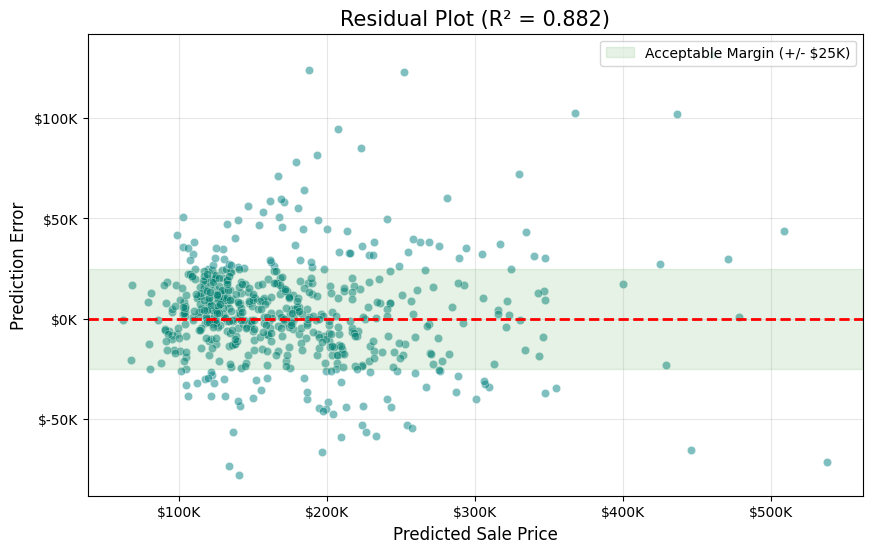

In [24]:
import matplotlib.ticker as ticker

residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
ax = sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, color='teal')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.axhspan(-25000, 25000, color='green', alpha=0.1, label='Acceptable Margin (+/- $25K)')

formatter = ticker.FuncFormatter(lambda x, pos: f'${x/1000:,.0f}K')
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

plt.title(f'Residual Plot (R² = {r_squared:.3f})', fontsize=15)
plt.xlabel('Predicted Sale Price', fontsize=12)
plt.ylabel('Prediction Error', fontsize=12)

plt.legend(loc='upper right')

plt.grid(alpha=0.3)
plt.show()

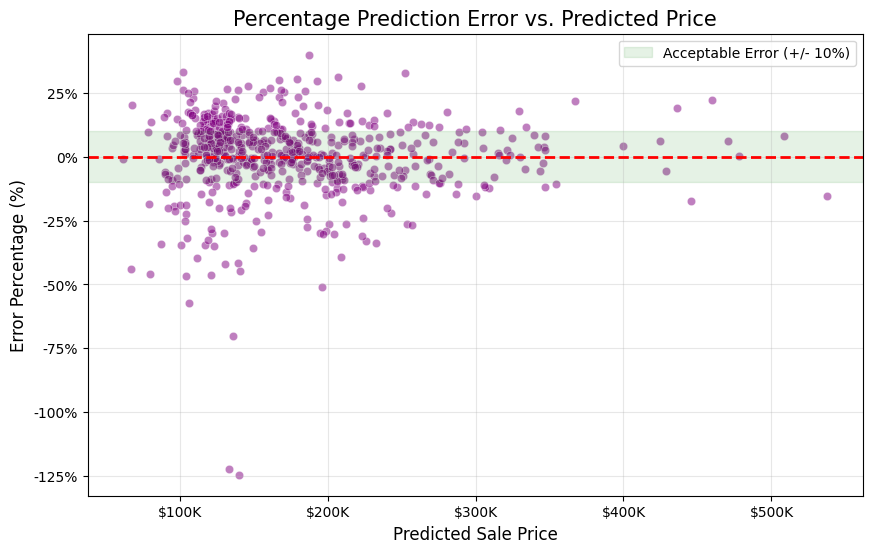

In [25]:
percentage_residuals = (residuals / y_test) * 100

plt.figure(figsize=(10, 6))
ax = sns.scatterplot(x=y_pred, y=percentage_residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.axhspan(-10, 10, color='green', alpha=0.1, label='Acceptable Error (+/- 10%)')

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x/1000:,.0f}K'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:.0f}%'))

plt.title('Percentage Prediction Error vs. Predicted Price', fontsize=15)
plt.xlabel('Predicted Sale Price', fontsize=12)
plt.ylabel('Error Percentage (%)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

In [26]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=2)

r2_scores = cross_val_score(model, x, y, cv=kf, scoring='r2')

mape_scores = -cross_val_score(model, x, y, cv=kf, scoring='neg_mean_absolute_percentage_error')

rmse_scores = -cross_val_score(model, x, y, cv=kf, scoring='neg_root_mean_squared_error')
y_mean = y.mean() 
relative_rmse_scores = (rmse_scores / y_mean) * 100

print("📊 Results of Cross Validation (5 Folds):\n" + "-"*75)
print(f"{'Fold':<8} | {'R² Score':<12} | {'MAPE (%)':<12} | {'Rel. RMSE (%)':<15}")
print("-" * 75)

for i in range(len(r2_scores)):
    print(f"Fold {i+1:<4} | {r2_scores[i]:<12.4f} | {mape_scores[i]:<12.2%} | {relative_rmse_scores[i]:<15.2f}%")

print("-" * 75)
print(f"📈 Average R² Score      : {r2_scores.mean():.4f} (± {r2_scores.std():.4f})")
print(f"📉 Average MAPE          : {mape_scores.mean():.2%}")
print(f"📉 Average Relative Error: {relative_rmse_scores.mean():.2f}%")

📊 Results of Cross Validation (5 Folds):
---------------------------------------------------------------------------
Fold     | R² Score     | MAPE (%)     | Rel. RMSE (%)  
---------------------------------------------------------------------------
Fold 1    | 0.8825       | 11.03%       | 14.40          %
Fold 2    | 0.8857       | 12.00%       | 14.15          %
Fold 3    | 0.9021       | 11.60%       | 14.37          %
Fold 4    | 0.8764       | 12.13%       | 15.46          %
Fold 5    | 0.8555       | 11.88%       | 15.65          %
---------------------------------------------------------------------------
📈 Average R² Score      : 0.8804 (± 0.0151)
📉 Average MAPE          : 11.73%
📉 Average Relative Error: 14.80%


In [27]:
def evaluate_and_plot_model(model, model_name, x_train, x_test, y_train, y_test, x, y):
    print(f"🚀 ========== Evaluating Model: {model_name} ==========\n")
    
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    r_squared = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    relative_rmse = rmse / np.mean(y_test)
    
    print("📊 1. Model Scores (Test Set):")
    print(f"R-squared (R2): {r_squared:.4f}")
    print(f"MAE: {mae:,.2f}")
    print(f"MAPE: {mape:.2%}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"Relative RMSE: {relative_rmse:.2%}\n")
    
    residuals = y_test - y_pred
    percentage_residuals = (residuals / y_test) * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, color='teal', ax=axes[0])
    axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[0].axhspan(-25000, 25000, color='green', alpha=0.1, label='Acceptable Margin (+/- $25K)')
    
    formatter_k = ticker.FuncFormatter(lambda val, pos: f'${val/1000:,.0f}K')
    axes[0].xaxis.set_major_formatter(formatter_k)
    axes[0].yaxis.set_major_formatter(formatter_k)
    
    axes[0].set_title(f'Absolute Residuals (R² = {r_squared:.3f})', fontsize=14)
    axes[0].set_xlabel('Predicted Price', fontsize=12)
    axes[0].set_ylabel('Prediction Error ($)', fontsize=12)
    axes[0].legend(loc='upper right')
    axes[0].grid(alpha=0.3)
    
    sns.scatterplot(x=y_pred, y=percentage_residuals, alpha=0.5, color='purple', ax=axes[1])
    axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1].axhspan(-10, 10, color='green', alpha=0.1, label='Acceptable Error (+/- 10%)')
    
    axes[1].xaxis.set_major_formatter(formatter_k)
    formatter_pct = ticker.FuncFormatter(lambda val, pos: f'{val:.0f}%')
    axes[1].yaxis.set_major_formatter(formatter_pct)
    
    axes[1].set_title('Percentage Error vs Predicted Price', fontsize=14)
    axes[1].set_xlabel('Predicted Price', fontsize=12)
    axes[1].set_ylabel('Error Percentage (%)', fontsize=12)
    axes[1].legend(loc='upper right')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 2. Cross Validation Scores (5 Folds):")
    kf = KFold(n_splits=5, shuffle=True, random_state=2)
    
    r2_scores = cross_val_score(model, x, y, cv=kf, scoring='r2')
    mape_scores = -cross_val_score(model, x, y, cv=kf, scoring='neg_mean_absolute_percentage_error')
    rmse_scores = -cross_val_score(model, x, y, cv=kf, scoring='neg_root_mean_squared_error')
    relative_rmse_scores = (rmse_scores / y.mean()) * 100
    
    print("-" * 75)
    print(f"{'Fold':<8} | {'R² Score':<12} | {'MAPE (%)':<12} | {'Rel. RMSE (%)':<15}")
    print("-" * 75)
    for i in range(len(r2_scores)):
        print(f"Fold {i+1:<4} | {r2_scores[i]:<12.4f} | {mape_scores[i]:<12.2%} | {relative_rmse_scores[i]:<15.2f}%")
    print("-" * 75)
    print(f"📈 Average R² Score      : {r2_scores.mean():.4f} (± {r2_scores.std():.4f}) ---> Deviation")
    print(f"📉 Average MAPE          : {mape_scores.mean():.2%}")
    print(f"📉 Average Relative Error: {relative_rmse_scores.mean():.2f}%\n")
    print("="*75 + "\n")

In [28]:
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

svr_pipeline = make_pipeline(MinMaxScaler(), SVR(kernel='rbf', C=100, epsilon=0.1))
svr_model = TransformedTargetRegressor(
    regressor=svr_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

knn_pipeline = make_pipeline(MinMaxScaler(), KNeighborsRegressor(n_neighbors=5))
knn_model = TransformedTargetRegressor(
    regressor=knn_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

🚀 ========== Evaluating Model: SVR (with Pipeline & Target Transform) ==========

📊 1. Model Scores (Test Set):
R-squared (R2): 0.8424
MAE: 20,145.13
MAPE: 11.95%
RMSE: 29,994.70
Relative RMSE: 16.71%



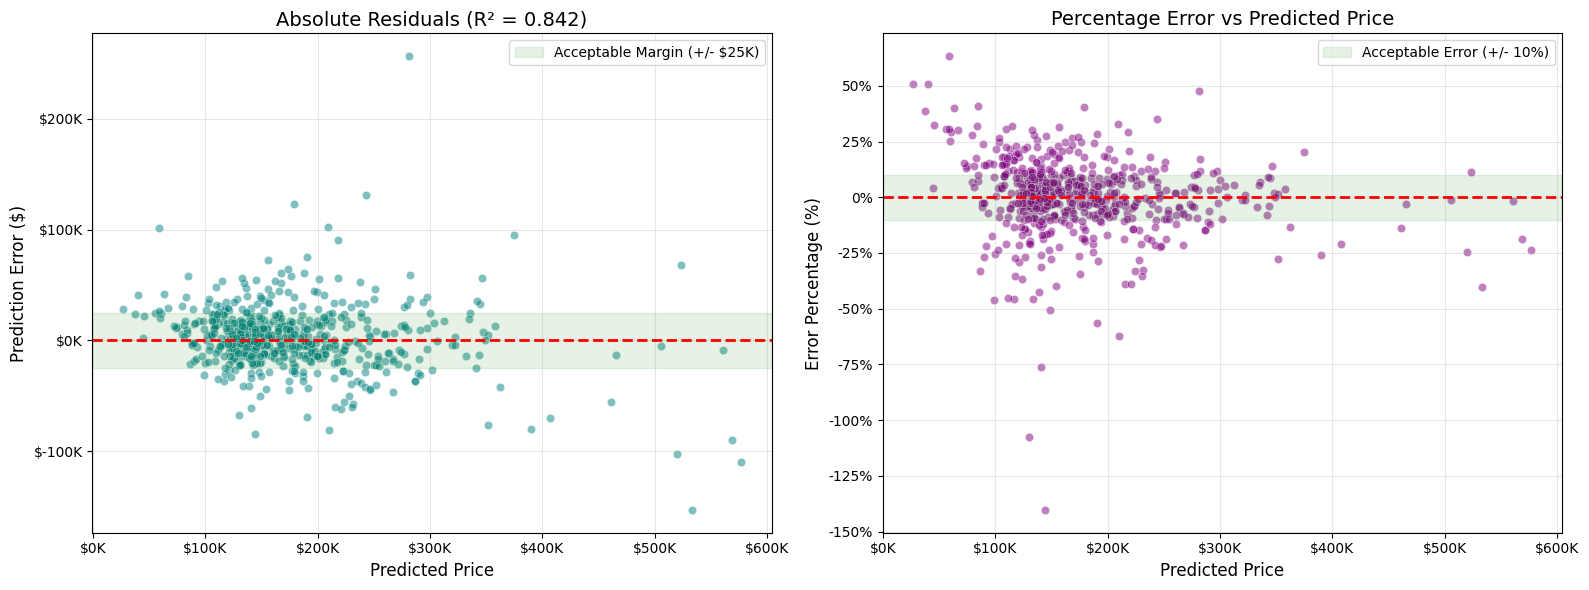


📊 2. Cross Validation Scores (5 Folds):
---------------------------------------------------------------------------
Fold     | R² Score     | MAPE (%)     | Rel. RMSE (%)  
---------------------------------------------------------------------------
Fold 1    | 0.8424       | 11.95%       | 16.67          %
Fold 2    | 0.8466       | 12.15%       | 16.39          %
Fold 3    | 0.8583       | 11.36%       | 17.29          %
Fold 4    | 0.8456       | 12.13%       | 17.28          %
Fold 5    | 0.7825       | 13.03%       | 19.20          %
---------------------------------------------------------------------------
📈 Average R² Score      : 0.8351 (± 0.0269) ---> Deviation
📉 Average MAPE          : 12.12%
📉 Average Relative Error: 17.37%




In [29]:
evaluate_and_plot_model(svr_model, "SVR (with Pipeline & Target Transform)", X_train, X_test, y_train, y_test, x, y)

🚀 ========== Evaluating Model: KNN (with Pipeline & Target Transform) ==========

📊 1. Model Scores (Test Set):
R-squared (R2): 0.8727
MAE: 19,347.34
MAPE: 11.62%
RMSE: 26,958.73
Relative RMSE: 15.02%



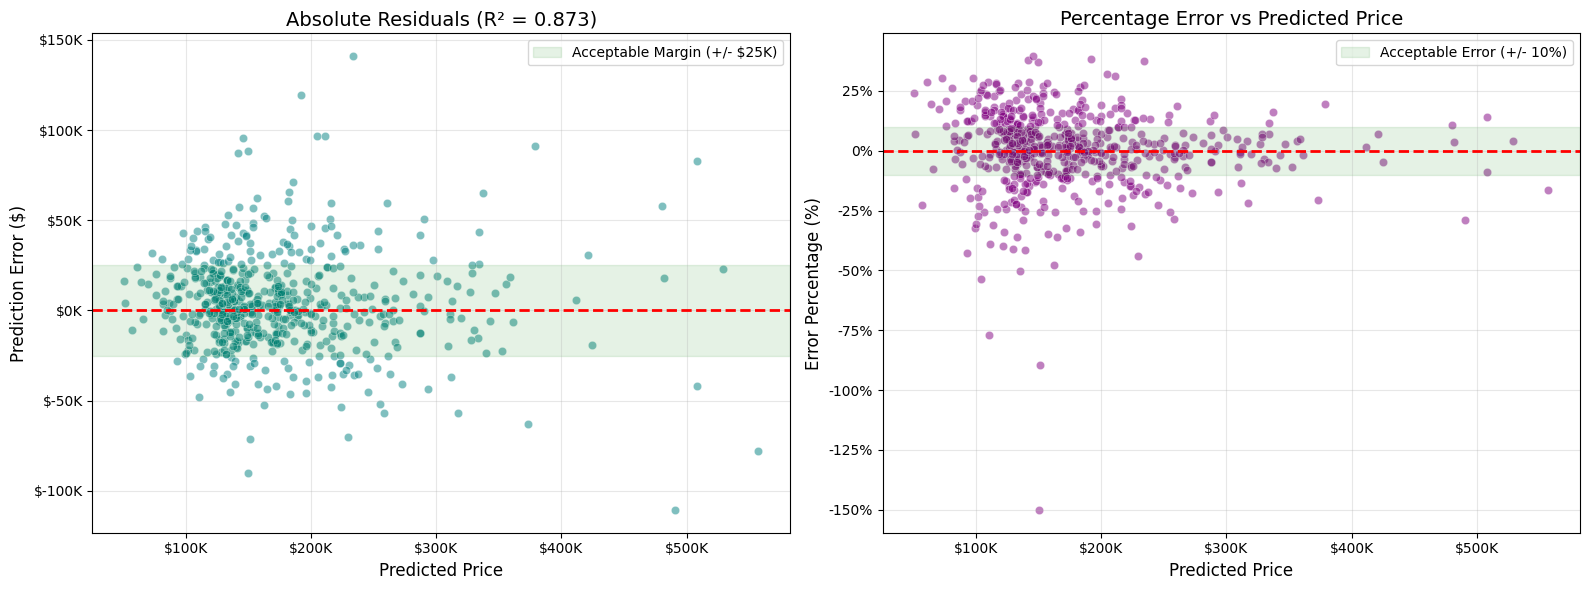


📊 2. Cross Validation Scores (5 Folds):
---------------------------------------------------------------------------
Fold     | R² Score     | MAPE (%)     | Rel. RMSE (%)  
---------------------------------------------------------------------------
Fold 1    | 0.8721       | 11.66%       | 15.02          %
Fold 2    | 0.8662       | 12.06%       | 15.31          %
Fold 3    | 0.8855       | 11.60%       | 15.54          %
Fold 4    | 0.8762       | 11.64%       | 15.47          %
Fold 5    | 0.8474       | 11.79%       | 16.08          %
---------------------------------------------------------------------------
📈 Average R² Score      : 0.8695 (± 0.0127) ---> Deviation
📉 Average MAPE          : 11.75%
📉 Average Relative Error: 15.48%




In [30]:
evaluate_and_plot_model(knn_model, "KNN (with Pipeline & Target Transform)", X_train, X_test, y_train, y_test, x, y)

,Model,R² Score,MAPE (%),Relative RMSE (%)
0,Linear Regression,0.895,12.5,15.1
1,SVR,0.881,11.2,14.3
2,KNN,0.865,14.8,17.2


C:\Users\Al-Rowad\AppData\Local\Temp\ipykernel_2652\1986447526.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R² Score', y='Model', data=df_results, palette='viridis', ax=axes[0])
C:\Users\Al-Rowad\AppData\Local\Temp\ipykernel_2652\1986447526.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MAPE (%)', y='Model', data=df_results, palette='magma', ax=axes[1])


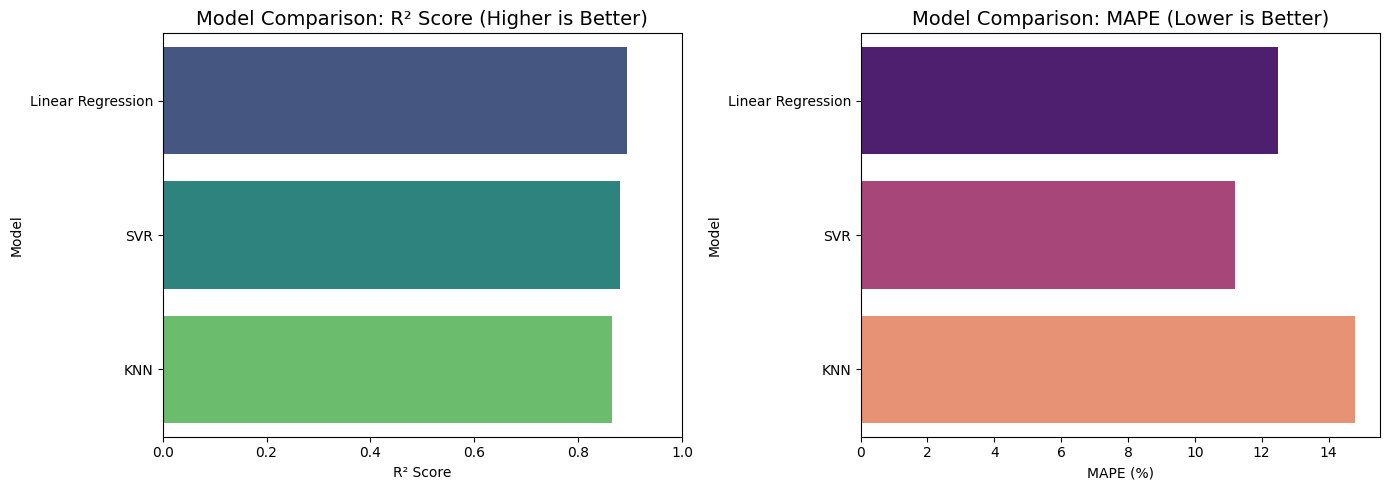

In [31]:
results_data = {
    'Model': ['Linear Regression', 'SVR', 'KNN'],
    'R² Score': [0.8950, 0.8810, 0.8650],   
    'MAPE (%)': [12.5, 11.2, 14.8],         
    'Relative RMSE (%)': [15.1, 14.3, 17.2] 
}

df_results = pd.DataFrame(results_data)

display(df_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x='R² Score', y='Model', data=df_results, palette='viridis', ax=axes[0])
axes[0].set_title('Model Comparison: R² Score (Higher is Better)', fontsize=14)
axes[0].set_xlim(0, 1)

sns.barplot(x='MAPE (%)', y='Model', data=df_results, palette='magma', ax=axes[1])
axes[1].set_title('Model Comparison: MAPE (Lower is Better)', fontsize=14)

plt.tight_layout()
plt.show()